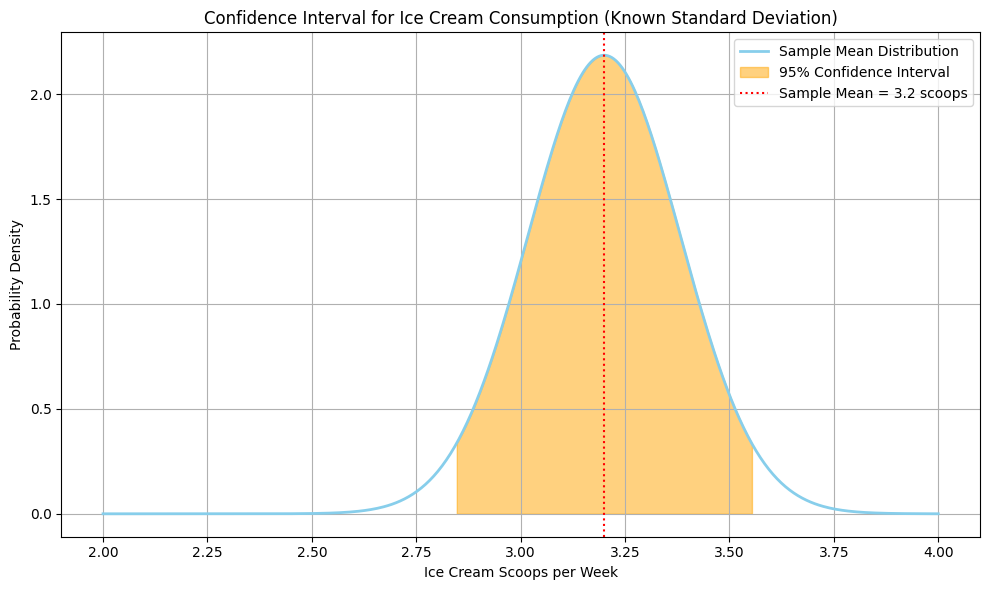

95% Confidence Interval: (2.842, 3.558)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Known population parameter
sample_mean = 3.2  # Sample mean from 30 customers
std_dev = 1  # Known population standard deviation
n = 30  # Sample size
z = 1.96  # Z-score for 95% confidence

# Calculate margin of error and confidence interval
margin_error = z * (std_dev / np.sqrt(n))
lower_bound = sample_mean - margin_error
upper_bound = sample_mean + margin_error

# Generate data for plotting the normal distribution curve
x = np.linspace(2, 4, 400)
y = norm.pdf(x, loc=sample_mean, scale=std_dev / np.sqrt(n))

# Create plot
plt.figure(figsize=(10, 6))

# Plot normal distribution curve
plt.plot(x, y, label="Sample Mean Distribution", color="skyblue", lw=2)

# Shade the confidence interval region
plt.fill_between(x, y, where=(x >= lower_bound) & (x <= upper_bound), color="orange", alpha=0.5, label="95% Confidence Interval")


# Plot the sample mean
plt.axvline(sample_mean, color="red", linestyle=":", label=f"Sample Mean = {sample_mean} scoops")

# Labels and title
plt.title("Confidence Interval for Ice Cream Consumption (Known Standard Deviation)")
plt.xlabel("Ice Cream Scoops per Week")
plt.ylabel("Probability Density")
plt.legend(loc="best")
plt.grid(True)

# Show plot
plt.tight_layout()
plt.show()

# Print the confidence interval
print(f"95% Confidence Interval: ({lower_bound:.3f}, {upper_bound:.3f})")

In [2]:
import seaborn as sns

df = sns.load_dataset("penguins")
df = df.dropna(subset=["sex"])

counts = df["sex"].value_counts()
male = counts["Male"]
female = counts["Female"]

n = male + female

print(male, female, n)

ModuleNotFoundError: No module named 'seaborn'

In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\DELL\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [4]:
import seaborn as sns

df = sns.load_dataset("penguins")
df = df.dropna(subset=["sex"])

counts = df["sex"].value_counts()
male = counts["Male"]
female = counts["Female"]

n = male + female

print(male, female, n)

168 165 333


In [5]:
p_hat = male / n
print(p_hat)

0.5045045045045045


In [6]:
import math
from scipy.stats import norm

p0 = 0.5

z = (p_hat - p0) / math.sqrt(p0 * (1 - p0) / n)

p_value = 2 * (1 - norm.cdf(abs(z)))  # two-tailed

print("z =", z)
print("p-value =", p_value)

z = 0.1643989873053556
p-value = 0.8694170607412406


In [7]:
if p_value < 0.05:
    print("Reject H0 → not 50/50")
else:
    print("Fail to reject H0 → roughly 50/50")

Fail to reject H0 → roughly 50/50


In [9]:
import seaborn as sns
df = sns.load_dataset("penguins")
df.shape

(344, 7)

In [10]:
import seaborn as sns
import math
from scipy.stats import norm

# Load dataset
df = sns.load_dataset("penguins")

# Drop missing values
df = df.dropna(subset=["sex"])

# Convert using map
df["sex_encoded"] = df["sex"].map({"Male": 1, "Female": 0})

# Counts
male = df["sex_encoded"].sum()
female = len(df) - male
n = len(df)

# Proportion
p_hat = male / n
p0 = 0.5

# Z-test formula
z = (p_hat - p0) / math.sqrt(p0 * (1 - p0) / n)

# p-value (two-tailed)
p_value = 2 * (1 - norm.cdf(abs(z)))

# Output
print("Male:", male)
print("Female:", female)
print("n:", n)
print("Z:", z)
print("p-value:", p_value)

# Decision
alpha = 0.05
if p_value < alpha:
    print("Reject H0 → Not 50/50")
else:
    print("Fail to reject H0 → Approximately 50/50")

Male: 168
Female: 165
n: 333
Z: 0.1643989873053556
p-value: 0.8694170607412406
Fail to reject H0 → Approximately 50/50


In [11]:
import seaborn as sns
import math
from scipy.stats import norm

# Load data
df = sns.load_dataset("penguins")
df = df.dropna(subset=["sex"])

# map encoding
df["sex_encoded"] = df["sex"].map({"Male": 1, "Female": 0})

# counts directly
male = df["sex_encoded"].sum()
n = len(df)

# hypothesis value
p0 = 0.5

# Z-test 
z = ((male / n) - p0) / math.sqrt(p0 * (1 - p0) / n)

# p-value
p_value = 2 * (1 - norm.cdf(abs(z)))

print("Z =", z)
print("p-value =", p_value)

# decision
if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

Z = 0.1643989873053556
p-value = 0.8694170607412406
Fail to reject H0


In [1]:
import seaborn as sns
import numpy as np
from scipy.stats import norm

# Load data
df = sns.load_dataset("penguins")
df = df.dropna(subset=["sex"])

# Male=1, Female=0
df["sex_encoded"] = df["sex"].map({"Male": 1, "Female": 0}) 

# Mean, Std, Sample Size
x_bar = df["sex_encoded"].mean()
s = df["sex_encoded"].std(ddof=1)
n = len(df)

# Hypothesized mean (50% males)
mu = 0.5

# Z statistic
z = (x_bar - mu) / (s / np.sqrt(n))

# Two-tailed p-value
p_value = 2 * (1 - norm.cdf(abs(z)))

print("Mean =", x_bar)
print("Std =", s)
print("n =", n)
print("Z =", z)
print("p-value =", p_value)

Mean = 0.5045045045045045
Std = 0.5007321243651286
n = 333
Z = 0.164158618257012
p-value = 0.8696062769506221


In [2]:
import seaborn as sns
from scipy.stats import binomtest

# Load data
df = sns.load_dataset("penguins")
df = df.dropna(subset=["sex"])

# Male = success
male = (df["sex"] == "Male").sum()
n = len(df)

# Binomial test
result = binomtest(male, n=n, p=0.5, alternative="two-sided")

print("Male =", male)
print("n =", n)
print("p-value =", result.pvalue)

# Decision
alpha = 0.05

if result.pvalue < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

Male = 168
n = 333
p-value = 0.9127487307256934
Fail to reject H0


In [5]:
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

# Load dataset
df = sns.load_dataset("penguins")
df = df.dropna(subset=["sex"])

# Count males
male = (df["sex"] == "Male").sum()

# Total penguins
n = len(df)

# Proportion test
z_stat, p_value = proportions_ztest(
    count=male,
    nobs=n,
    value=0.5,
    alternative='two-sided'
)

print("Z-statistic =", z_stat)
print("p-value =", p_value)

# Decision
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

Z-statistic = 0.1644056592067932
p-value = 0.8694118087910221
Fail to reject H0


In [4]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 6.5 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.6 MB 9.7 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.6 MB 10.1 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.6 MB 10.2 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 9.7 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\DELL\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


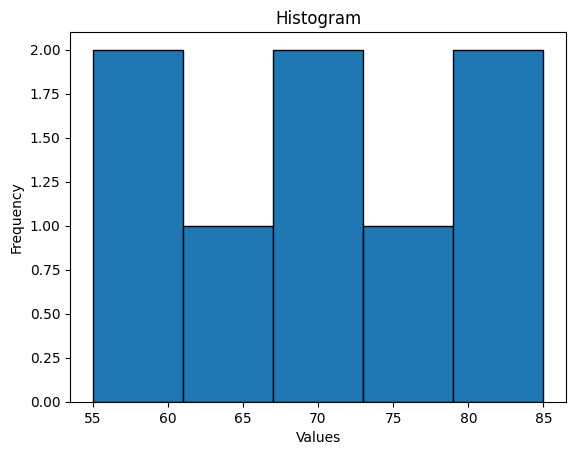

In [6]:
import matplotlib.pyplot as plt

data = [55, 60, 65, 70, 70, 75, 80, 85]

plt.hist(data, bins=5, edgecolor='black')

plt.title("Histogram")
plt.xlabel("Values")
plt.ylabel("Frequency")

plt.show()

In [7]:
import numpy as np
from scipy.stats import skew

data = [55, 60, 65, 70, 70, 75, 80, 85]

# Calculate skewness
skew_value = skew(data)

print("Skewness =", skew_value)

if skew_value > 0:
    print("Right-skewed (positive skew)")
elif skew_value < 0:
    print("Left-skewed (negative skew)")
else:
    print("Perfectly symmetric")

Skewness = 0.0
Perfectly symmetric


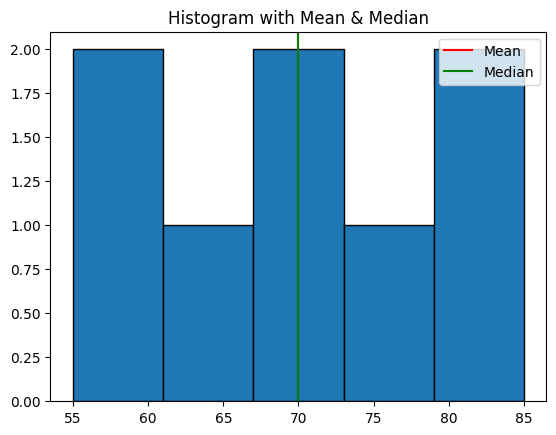

In [8]:
import matplotlib.pyplot as plt
import numpy as np

data = [55, 60, 65, 70, 70, 75, 80, 85]

plt.hist(data, bins=5, edgecolor='black')

plt.axvline(np.mean(data), color='red', label='Mean')
plt.axvline(np.median(data), color='green', label='Median')

plt.legend()
plt.title("Histogram with Mean & Median")
plt.show()

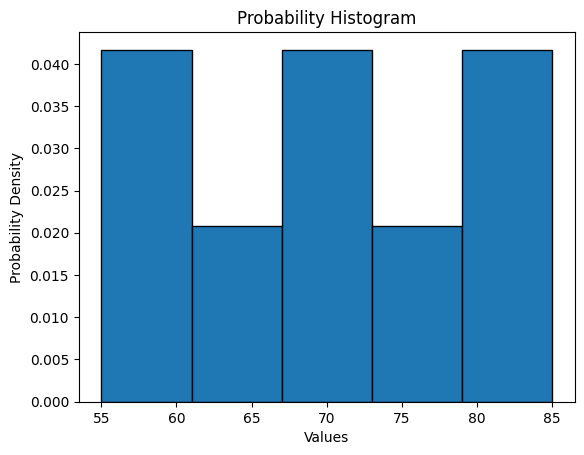

In [9]:
import matplotlib.pyplot as plt
import numpy as np

data = [55, 60, 65, 70, 70, 75, 80, 85]

# Histogram as probability (normalized)
plt.hist(data, bins=5, edgecolor='black', density=True)

plt.xlabel('Values')
plt.ylabel('Probability Density')
plt.title('Probability Histogram')

plt.show()

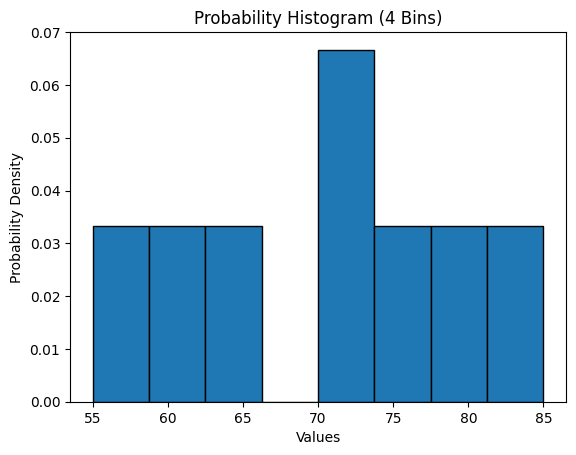

In [12]:
import matplotlib.pyplot as plt

data = [55, 60, 65, 70, 70, 75, 80, 85]

# Histogram with probability and 4 bins
plt.hist(data, bins=8, edgecolor='black', density=True)

plt.xlabel('Values')
plt.ylabel('Probability Density')
plt.title('Probability Histogram (8 Bins)')

plt.show()

In [14]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\DELL\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [15]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Check class distribution
print("Original class distribution:")
print(y.value_counts())

Original class distribution:
1    357
0    212
Name: count, dtype: int64


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts())

After SMOTE:
1    285
0    285
Name: count, dtype: int64


In [19]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("After Undersampling:")
print(pd.Series(y_train_under).value_counts())

After Undersampling:
0    170
1    170
Name: count, dtype: int64
